# 16 &middot; Mass-Spring Actuation: Pulling Surface Tendons to Steer a Beam

Tutorial&nbsp;15 bent a beam with a pneumatic chamber. Here the actuators are two
**contractile springs** (tendons) glued along the top and bottom surface of a neo-Hookean
cantilever. A spring (tutorial&nbsp;11) stores $\tfrac12 k\,(l(x)-l_0^\star)^2$ with
$l(x)=\lVert x_i-x_j\rVert$, and a tendon *actuates* by lowering its commanded rest length
$l_0^\star$, which reels its two endpoints in. Ramping $l_0^\star$ and re-solving the
quasistatic equilibrium at every step curls the beam up, down, or anywhere in between:

$$
x^\star = \arg\min_x\; E_{\text{neo}}(x)
+ \sum_{s\in\{\text{top},\text{bot}\}} \tfrac12 k\,\bigl(l_s(x)-l_{0,s}^\star\bigr)^2
+ \tfrac12\lVert x_{\text{pin}}-X_{\text{pin}}\rVert_K^2
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils

NOTEBOOK = "016_mass_spring_actuation"                           # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)  # results/016_mass_spring_actuation/
MEDIA_DIR = "media"                                              # tracked copies for the website
# beam mesh
NX, NY = 29, 7                          # grid vertices along x and y
LENGTH, HEIGHT = 3.5, 0.8               # beam size
# material
MATERIAL = "macklin-mueller-neo-hookean"
YM, PR = 1e4, 0.45                      # Young's modulus, Poisson ratio
# tendons and clamp
K_TENDON = 2e3                          # tendon spring stiffness k
K_PIN = 1e9                             # penalty stiffness clamping the left wall
# quasistatic actuation
N_STEPS = 28                            # poses per ramp, from the natural rest length to the command
NEWTON_ITERS = 40                       # max Newton iterations per ramp step
TOP_RATIO = 0.4                         # first experiment: top tendon commanded to 40% of its natural length
DESIGNS = [                             # steering comparison: (label, top ratio, bottom ratio)
    ("contract top  ->  curls up", 0.4, 1.0),
    ("contract both  ->  no net bend", 0.4, 0.4),
    ("contract bottom  ->  curls down", 1.0, 0.4),
]
ASYMS = [-0.4, -0.2, 0.0, 0.2, 0.4]     # differential command d: top x(1+d), bottom x(1-d)
# validation
FD_STEP = 1e-6                          # central-difference step for the gradient check
FD_NOISE = 0.02                         # jitter of the free vertices at the gradient check
FD_RATIOS = (0.6, 1.3)                  # commanded (top, bottom) ratios at the gradient check
SEED = 0                                # RNG seed for that jitter
FPS = 18                                # animation frame rate
# colors
TOP_C, BOT_C = "#c0392b", "#08519c"     # top / bottom tendon
WALL_FACE, WALL_EDGE = "#cfe8df", "#2a7f62"

## A beam with two surface tendons

A libigl grid, centered and scaled to `LENGTH` x `HEIGHT`. The top tendon is a single spring
from the top-left to the top-middle vertex, and the bottom tendon mirrors it, so each spans the
left half next to the clamped wall, where it has the most leverage. A tendon's natural rest
length is the distance it covers at rest. The left wall (squares) is pinned.

mesh: 203 vertices, 336 triangles, 7 pinned
tendon natural lengths: top 1.750, bottom 1.750


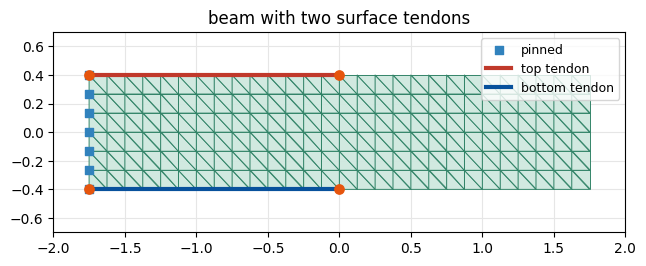

In [2]:
V, T = igl.triangulated_grid(NX, NY)                     # unit square, NX x NY vertices
X = (V - 0.5) * np.array([LENGTH, HEIGHT])               # centered LENGTH x HEIGHT beam
n, dim = X.shape
mid = NX // 2
E_top = np.array([[(NY - 1) * NX, (NY - 1) * NX + mid]])  # top-left -> top-middle
E_bot = np.array([[0, mid]])                              # bottom-left -> bottom-middle
E_act = np.vstack([E_top, E_bot])                         # row 0 top, row 1 bottom
l0_natural = simkit.edge_lengths(X, E_act)               # natural rest lengths (top, bottom)
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
print(f"mesh: {n} vertices, {len(T)} triangles, {len(pin_idx)} pinned")
print(f"tendon natural lengths: top {l0_natural[0]:.3f}, bottom {l0_natural[1]:.3f}")

fig, ax = plt.subplots(figsize=(8, 2.6))
utils.plot_mesh(ax, X, T, pins=pin_idx, facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.7,
                lims=((-2.0, 2.0), (-0.7, 0.7)), title="beam with two surface tendons")
for (i, j), c, lbl in zip(E_act, [TOP_C, BOT_C], ["top tendon", "bottom tendon"]):
    ax.plot(X[[i, j], 0], X[[i, j], 1], "-", color=c, lw=3.0, zorder=6, label=lbl)
    ax.scatter(X[[i, j], 0], X[[i, j], 1], s=45, color="#e6550d", zorder=7)
ax.legend(loc="upper right", fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_mesh.png"))
plt.show()

## Constant operators

Built once from the rest shape: the deformation Jacobian `J`, triangle areas `vol` (all equal on
this grid, so the beam is uniformly stiff), the per-triangle Lamé parameters, and the clamp
penalty `(Q_pin, b_pin)`. Its constant `c_pin` makes $E_{\text{pin}}=\tfrac12\lVert x_{\text{pin}}-X_{\text{pin}}\rVert_K^2$
exactly zero at the clamp. Without it the total energy sits near $-10^{10}$, and round-off swamps
small energy differences. Each tendon is one spring of unit weight: $\tfrac12 k (l-l_0^\star)^2$.

In [3]:
J = simkit.deformation_jacobian(X, T)
vol = simkit.volume(X, T)
mu_s, lam_s = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu_s)
lam = np.full((len(T), 1), lam_s)
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)
c_pin = 0.5 * K_PIN * np.sum(X[pin_idx] ** 2)      # makes E_pin zero at the clamp
k_tendon = np.full((1, 1), K_TENDON)                   # per-spring stiffness
w_tendon = np.ones((1, 1))                             # per-spring weight
print(f"triangle area {vol.min():.4f} .. {vol.max():.4f}, mu = {mu_s:.0f}, lambda = {lam_s:.0f}")

triangle area 0.0083 .. 0.0083, mu = 3448, lambda = 31034


## The tendon-beam system

`tendon_beam_system(l0_top, l0_bot)` is the objective for given commanded rest lengths, one
simkit term per line: neo-Hookean elasticity, one single-edge `mass_springs` term per tendon,
and the pin. A tendon's gradient $k(l-l_0^\star)\,\partial l/\partial x$ is a Hooke force of
magnitude $k(l-l_0^\star)$ along the edge. Its $2\times2$ Hessian block has eigenvalues $k$
along the edge and $k(1-l_0^\star/l)$ across it, negative when the tendon is compressed
($l<l_0^\star$), so by default the spring and elastic Hessians are PSD-projected (`psd=True`) to
keep Newton's steps downhill. `psd=False` keeps the exact Hessian, for a comparison below.

In [4]:
def tendon_beam_system(l0_top, l0_bot, psd=True):
    """Neo-Hookean beam + top and bottom tendon springs + clamped left wall, in stacked positions x."""
    l0_t = np.full((1, 1), l0_top)
    l0_b = np.full((1, 1), l0_bot)

    def energy_func(x):
        U = x.reshape(n, dim)
        E_elastic = simkit.energies.elastic_energy_x(U, J, mu, lam, vol, MATERIAL)
        E_tendon_top = simkit.energies.mass_springs_energy_x(U, E_top, k_tendon, w_tendon, l0_t)
        E_tendon_bot = simkit.energies.mass_springs_energy_x(U, E_bot, k_tendon, w_tendon, l0_b)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin) + c_pin
        E_total = E_elastic + E_tendon_top + E_tendon_bot + E_pin
        return E_total

    def gradient_func(x):
        U = x.reshape(n, dim)
        g_elastic = simkit.energies.elastic_gradient_x(U, J, mu, lam, vol, MATERIAL)
        g_tendon_top = simkit.energies.mass_springs_gradient_x(U, E_top, k_tendon, w_tendon, l0_t)
        g_tendon_bot = simkit.energies.mass_springs_gradient_x(U, E_bot, k_tendon, w_tendon, l0_b)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_total = g_elastic + g_tendon_top + g_tendon_bot + g_pin
        return g_total

    def hessian_func(x):
        U = x.reshape(n, dim)
        H_elastic = simkit.energies.elastic_hessian_x(U, J, mu, lam, vol, MATERIAL, psd=psd)
        H_tendon_top = simkit.energies.mass_springs_hessian_x(U, E_top, k_tendon, w_tendon, l0_t, psd=psd)
        H_tendon_bot = simkit.energies.mass_springs_hessian_x(U, E_bot, k_tendon, w_tendon, l0_b, psd=psd)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_elastic + H_tendon_top + H_tendon_bot + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

A central-difference check of `gradient_func` before solving anything. The free vertices are
jittered by `FD_NOISE`, and the tendons are commanded to `FD_RATIOS` of their natural length,
so the top one pulls and the bottom one is compressed. The relative error is at round-off level,
so the assembled gradient is right.

In [5]:
rng = np.random.default_rng(SEED)
free = np.setdiff1d(np.arange(n), pin_idx)
U_test = X.copy()
U_test[free] += FD_NOISE * rng.standard_normal((len(free), dim))
x_test = U_test.reshape(-1, 1)
energy_func, gradient_func, hessian_func = tendon_beam_system(*(np.array(FD_RATIOS) * l0_natural))
g_analytic = gradient_func(x_test).ravel()
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
print(f"relative gradient error |g_fd - g| / |g| = {np.linalg.norm(g_fd - g_analytic) / np.linalg.norm(g_analytic):.2e}")

relative gradient error |g_fd - g| / |g| = 1.49e-10


## Quasistatically contracting the top tendon

No time, mass or velocity. `actuate` ramps each commanded rest length linearly from its natural
value to `ratio` x natural over `N_STEPS` poses, rebuilds the system at every pose and
Newton-solves it warm-started from the previous one. It records the poses, the tendon lengths
$l$ and the tensions $f=k(l-l_0^\star)$ (positive when pulling). `tip_angle` turns the free end's
mean rise over the span into an angle. First, the top tendon alone is commanded to `TOP_RATIO`.

In [6]:
def tip_angle(U):
    """Deflection angle (deg) of the cantilever's free end relative to rest."""
    tip = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
    rise = U[tip, 1].mean() - X[tip, 1].mean()
    return np.degrees(np.arctan2(rise, LENGTH))


def actuate(top_ratio, bot_ratio):
    """Ramp the commanded rest lengths to ratio x natural, solving the equilibrium at every pose.
    Returns the poses, the commanded rest lengths, the tendon lengths and their tensions."""
    ramp = np.linspace(0.0, 1.0, N_STEPS)
    l0_cmd = l0_natural * (1.0 + ramp[:, None] * (np.array([top_ratio, bot_ratio]) - 1.0))
    x = X.reshape(-1, 1).copy()
    states = [X.copy()]
    for l0_top, l0_bot in l0_cmd[1:]:
        energy_func, gradient_func, hessian_func = tendon_beam_system(l0_top, l0_bot)
        x = simkit.solvers.newton_solver(x, energy_func, gradient_func, hessian_func,
                                         max_iter=NEWTON_ITERS, do_line_search=True)
        states.append(x.reshape(n, dim).copy())
    lengths = np.array([simkit.edge_lengths(U, E_act) for U in states])
    tensions = K_TENDON * (lengths - l0_cmd)
    return np.array(states), l0_cmd, lengths, tensions


states_top, l0_cmd_top, lengths_top, tensions_top = actuate(TOP_RATIO, 1.0)
angles_top = np.array([tip_angle(U) for U in states_top])
print(f"top tendon: commanded {l0_cmd_top[-1, 0]:.3f}, length {lengths_top[0, 0]:.3f} -> {lengths_top[-1, 0]:.3f}, "
      f"tension {tensions_top[-1, 0]:.0f}")
print(f"bottom tendon (not actuated): length {lengths_top[0, 1]:.3f} -> {lengths_top[-1, 1]:.3f}, "
      f"tension {tensions_top[-1, 1]:.0f}")
print(f"tip deflection angle: {angles_top[-1]:+.1f} deg")

top tendon: commanded 0.700, length 1.750 -> 1.113, tension 827
bottom tendon (not actuated): length 1.750 -> 1.864, tension 227
tip deflection angle: +29.8 deg


The top tendon only shortens to 1.113, far from its 0.700 command: the beam's bending stiffness
holds it back, and the leftover stretch is the tension it pulls with, 827 at full actuation. The
passive bottom tendon is dragged longer as the beam curls, so it pulls too (227) and resists the
bend. Solid lines are lengths $l$, dashed lines commands $l_0^\star$.

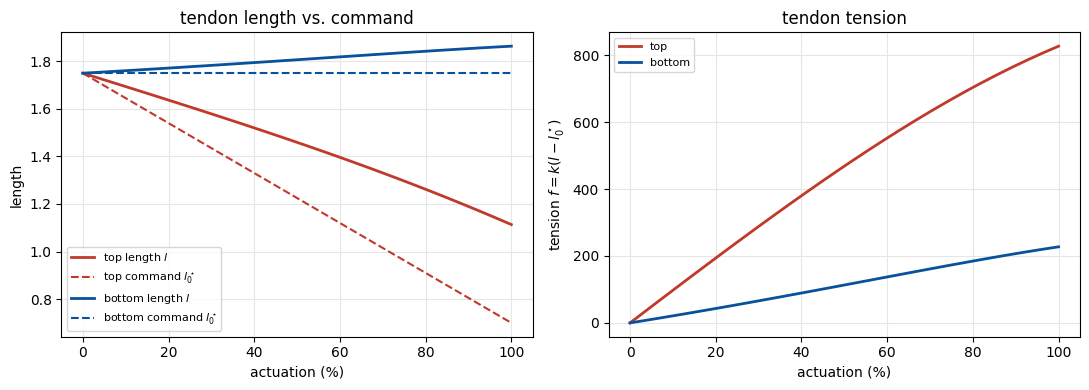

In [7]:
act = np.linspace(0, 100, N_STEPS)                        # actuation (%)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for s, (c, name) in enumerate(zip([TOP_C, BOT_C], ["top", "bottom"])):
    axes[0].plot(act, lengths_top[:, s], "-", color=c, lw=2, label=f"{name} length $l$")
    axes[0].plot(act, l0_cmd_top[:, s], "--", color=c, lw=1.5, label=f"{name} command $l_0^\\star$")
    axes[1].plot(act, tensions_top[:, s], "-", color=c, lw=2, label=name)
axes[0].set(xlabel="actuation (%)", ylabel="length", title="tendon length vs. command")
axes[1].set(xlabel="actuation (%)", ylabel="tension $f = k(l - l_0^\\star)$", title="tendon tension")
for ax in axes:
    ax.grid(True, color="0.9")
    ax.legend(fontsize=8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tendon_response.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_tendon_response.png"))
plt.show()

## Newton convergence, and the cost of the projection

The final ramp step, re-solved from the previous pose with `return_info=True`, once with the
projected Hessian used throughout and once with the exact one. The projection guarantees a
descent direction at any pose, but it also drops the negative curvature of compressed elements,
so $\lVert\nabla E\rVert$ falls only linearly, by about 30% per iteration, and stops after 26
iterations when the step drops below the tolerance. Near this stable equilibrium the full Hessian
is positive definite anyway, so exact Newton converges quadratically in 5 iterations, to the same
pose within $3\cdot10^{-5}$ and with a far smaller gradient.

projected (psd=True)   26 iterations, final |grad E| = 7.2e-03, max distance to the ramp's pose 0.0e+00
exact (psd=False)       5 iterations, final |grad E| = 1.8e-07, max distance to the ramp's pose 2.6e-05


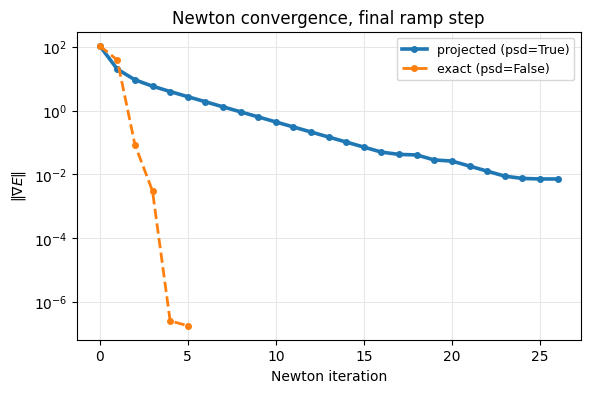

In [8]:
x_prev = states_top[-2].reshape(-1, 1)
grad_norms = {}
for label, psd in [("projected (psd=True)", True), ("exact (psd=False)", False)]:
    energy_func, gradient_func, hessian_func = tendon_beam_system(*l0_cmd_top[-1], psd=psd)
    x_last, info = simkit.solvers.newton_solver(x_prev, energy_func, gradient_func, hessian_func,
                                                max_iter=NEWTON_ITERS, do_line_search=True, return_info=True)
    grad_norms[label] = [np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x_last))]
    print(f"{label:22s} {len(info['alphas']):2d} iterations, final |grad E| = {grad_norms[label][-1]:.1e}, "
          f"max distance to the ramp's pose {np.abs(x_last - states_top[-1].reshape(-1, 1)).max():.1e}")

fig, ax = plt.subplots(figsize=(6.5, 4))
utils.residual_plot(grad_norms, ax=ax, markers=True, xlabel="Newton iteration", ylabel=r"$\|\nabla E\|$",
                    title="Newton convergence, final ramp step")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_newton_convergence.png"))
plt.show()

## Where the beam deforms

Two scalar fields on the fully actuated pose: the elastic energy density $\psi(F)$ per triangle
(left, log scale) and the displacement magnitude $\lVert u\rVert$ per vertex (right). The strain
energy lives in the left half, between the wall and the tendon anchors, and peaks at the top
anchor, where the whole tendon force enters through one vertex and kinks the surface. The outer
half stores almost nothing (dark): it is carried nearly rigidly, and its displacement grows
steadily toward the tip.

energy density: max 1504 (triangle with rest centroid [-0.04  0.36]), median 34.6


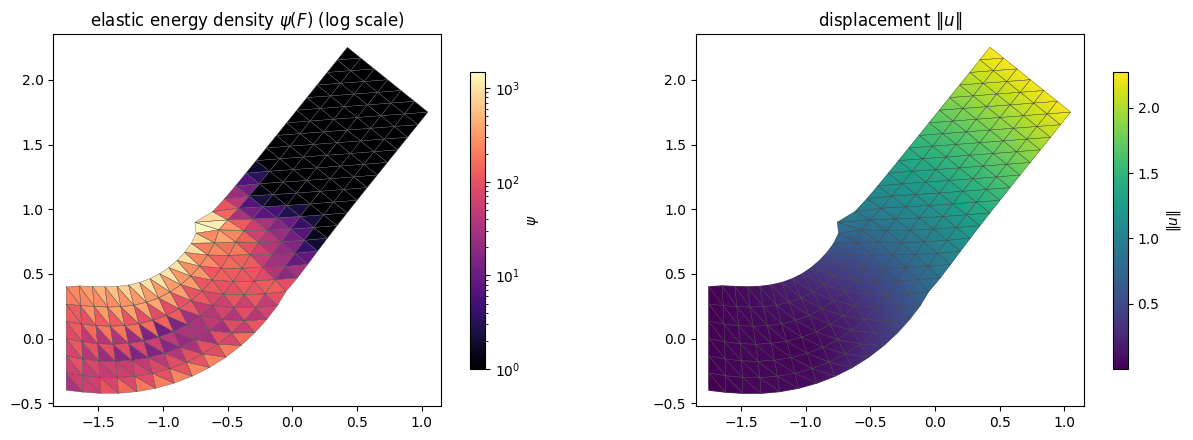

In [9]:
U_top = states_top[-1]
F_top = simkit.deformation_gradient(X, T, U_top)
psi_top = simkit.energies.elastic_energy_element_F(F_top, mu, lam, MATERIAL)
disp_top = np.linalg.norm(U_top - X, axis=1)
print(f"energy density: max {psi_top.max():.0f} (triangle with rest centroid "
      f"{X[T[np.argmax(psi_top)]].mean(axis=0).round(2)}), median {np.median(psi_top):.1f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
utils.plot_scalar_field(axL, U_top, T, psi_top, cmap="magma", norm=LogNorm(vmin=1.0, vmax=psi_top.max()),
                        title=r"elastic energy density $\psi(F)$ (log scale)", label=r"$\psi$")
utils.plot_scalar_field(axR, U_top, T, disp_top, cmap="viridis", title=r"displacement $\|u\|$",
                        label=r"$\|u\|$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_fields.png"))
plt.show()

The whole ramp as a movie: the top tendon (red) reels in its endpoint, the passive bottom tendon
(blue) is stretched, and the right panel traces the tip angle as it climbs to +29.8°.

In [10]:
fig, anim = utils.animate_tendon_trace(states_top, T, E_act, act, {"tip angle": angles_top},
                                       tendon_colors=[TOP_C, BOT_C], pins=pin_idx, fps=FPS,
                                       title="contract top tendon -> beam curls up",
                                       xlabel="actuation (%)", ylabel="tip deflection angle (deg)",
                                       trace_title="angle vs. actuation", trace_colors={"tip angle": "#444"})
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "tendon_contract.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "016_tendon_contract.mp4"))
plt.close(fig)
utils.embed_video(video)

## Steering: which tendon you pull sets the bend

The two commanded rest lengths are the actuator's control inputs. We run the same ramp for the
three patterns in `DESIGNS` and play them side by side. Pulling the top tendon curls the beam
up (+29.8°), pulling the bottom one curls it down (−30.2°). Pulling both equally is symmetric, so
the left half shortens but barely bends: the leftover +1.1° (and the 0.4° up/down mismatch) comes
from the grid's diagonals, which all lean the same way.

In [11]:
panels = []
for label, top_ratio, bot_ratio in DESIGNS:
    states, _, _, _ = actuate(top_ratio, bot_ratio)
    panels.append({"states": states, "T": T, "E_act": E_act, "title": label, "pins": pin_idx})
    print(f"{label:34s} tip angle = {tip_angle(states[-1]):+.1f} deg")

fig, anim = utils.animate_tendon_panels(panels, tendon_colors=[TOP_C, BOT_C], fps=FPS, figsize=(13.5, 5.6),
                                        suptitle="same contraction, three tendon patterns")
fig.subplots_adjust(top=0.87, bottom=0.08)             # room for the suptitle and tick labels
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "tendon_steering.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "016_tendon_steering.mp4"))
plt.close(fig)
utils.embed_video(video)

contract top  ->  curls up         tip angle = +29.8 deg


contract both  ->  no net bend     tip angle = +1.1 deg


contract bottom  ->  curls down    tip angle = -30.2 deg


## A deflection gallery

One differential knob $d$ gives continuous steering: the top tendon is commanded to $(1+d)\times$
and the bottom to $(1-d)\times$ its natural length, for each $d$ in `ASYMS`. $d<0$ shortens the
top and lengthens the bottom (curls up), $d>0$ does the reverse (curls down), and $d=0$ is the
rest beam. Each final pose is drawn over its rest shape (gray).

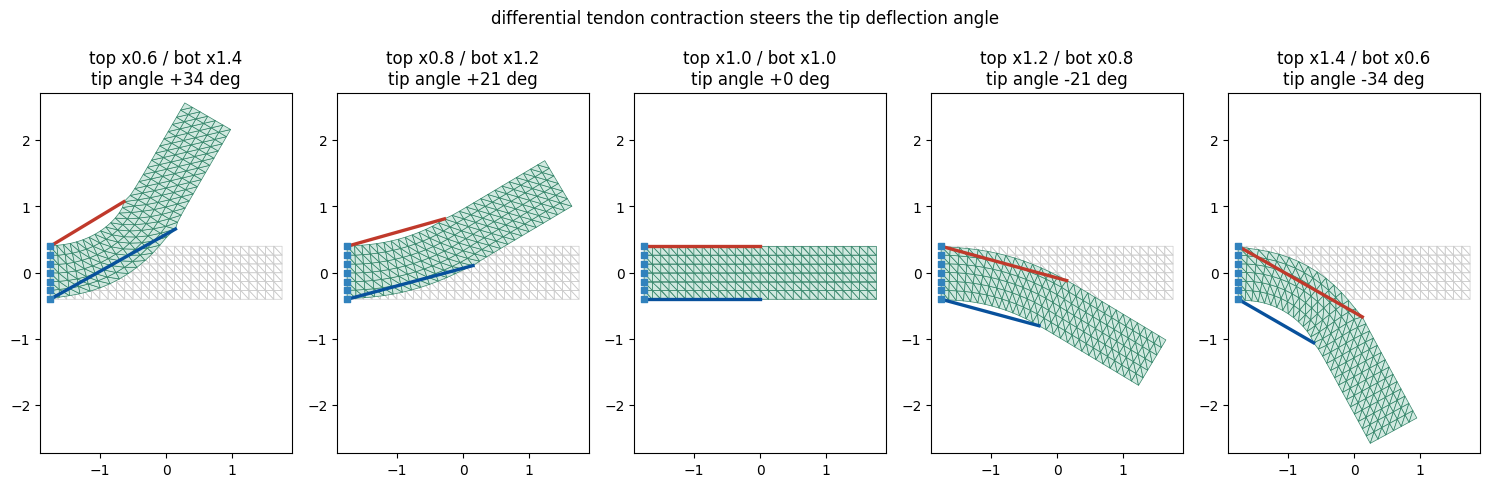

In [12]:
gallery = []
for d in ASYMS:
    states, l0_cmd, lengths, tensions = actuate(1 + d, 1 - d)
    gallery.append({"d": d, "U": states[-1], "l0": l0_cmd[-1], "l": lengths[-1], "f": tensions[-1],
                    "angle": tip_angle(states[-1])})

lims = utils.auto_limits([X] + [case["U"] for case in gallery], pad=0.15)
fig, axes = plt.subplots(1, len(ASYMS), figsize=(3.0 * len(ASYMS), 4.4), squeeze=False)
for ax, case in zip(axes[0], gallery):
    utils.TendonMeshArtist(ax, case["U"], T, E_act, colors=[TOP_C, BOT_C], rest=X, pins=pin_idx,
                           facecolor=WALL_FACE, edgecolor=WALL_EDGE, lw=0.5, tendon_lw=2.4,
                           node_size=0, pin_size=16)
    utils.setup_axes(ax, *lims, grid=False, title=f"top x{1 + case['d']:.1f} / bot x{1 - case['d']:.1f}\n"
                                                  f"tip angle {np.round(case['angle']) + 0.0:+.0f} deg")
fig.tight_layout()
fig.suptitle("differential tendon contraction steers the tip deflection angle", y=1.08)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tendon_gallery.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_tendon_gallery.png"))
plt.show()

## The steering curve, and why the Hessian is projected

Tip angle (left) and final tendon tensions (right) against $d$. The curve is nearly linear and
antisymmetric (±21° at $d=\pm0.2$, ±34° at $\pm0.4$), so one knob steers the tip. The lengthened
tendon cannot reach its command: it is compressed ($f<0$) and pushes, which adds to the bend.
That is where a raw tendon Hessian block goes indefinite, and the printout checks it at
$d=-0.4$ against the eigenvalues $k$ and $k(1-l_0^\star/l)$.

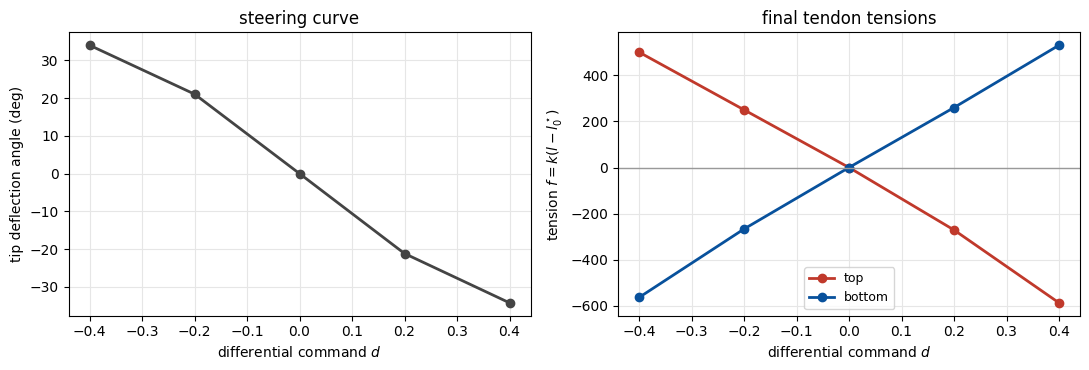

d = -0.4: bottom tendon l = 2.167 < l0* = 2.450 (compressed)
raw Hessian block eigenvalues [-260.8 2000. ] -> PSD-projected [   0. 2000.]


In [13]:
ds = np.array([case["d"] for case in gallery])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.8))
axL.plot(ds, [case["angle"] for case in gallery], "-o", color="#444", lw=2)
axL.set(xlabel="differential command $d$", ylabel="tip deflection angle (deg)", title="steering curve")
for s, (c, name) in enumerate(zip([TOP_C, BOT_C], ["top", "bottom"])):
    axR.plot(ds, [case["f"][s] for case in gallery], "-o", color=c, lw=2, label=name)
axR.axhline(0, color="0.6", lw=1)
axR.set(xlabel="differential command $d$", ylabel="tension $f = k(l - l_0^\\star)$", title="final tendon tensions")
axR.legend(fontsize=9)
for ax in (axL, axR):
    ax.grid(True, color="0.9")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "steering_curve.png"),
                              copy_to=os.path.join(MEDIA_DIR, "016_steering_curve.png"))
plt.show()

case = gallery[0]                                       # d = ASYMS[0]: the bottom tendon is lengthened
U = case["U"]
d_bot = U[E_bot[:, 0]] - U[E_bot[:, 1]]                 # bottom tendon's edge vector
H_raw = simkit.energies.mass_springs_hessian_element_d(d_bot, k_tendon, np.array([[case["l0"][1]]]))
H_psd = simkit.psd_project(H_raw)
print(f"d = {case['d']:+.1f}: bottom tendon l = {case['l'][1]:.3f} < l0* = {case['l0'][1]:.3f} (compressed)")
print(f"raw Hessian block eigenvalues {np.linalg.eigvalsh(H_raw[0]).round(1)} -> "
      f"PSD-projected {np.linalg.eigvalsh(H_psd[0]).round(1)}")

### Takeaways

* A contractile tendon is a **spring whose rest length you command**: lowering $l_0^\star$ in
  $\tfrac12 k(l-l_0^\star)^2$ pulls its endpoints together with the Hooke force $k(l-l_0^\star)$.
* Glued to a clamped neo-Hookean beam, ramping $l_0^\star$ and re-solving with Newton gives
  **quasistatic** actuation: the same recipe as the pneumatic chamber, with an off-center spring.
* A tendon commanded longer than it can reach is **compressed** and its raw Hessian block goes
  indefinite. PSD projection guarantees descent directions, at the price of linear convergence
  near the solution, where exact Newton is quadratic.
* **Where and how hard you pull is steering**: top curls up, bottom curls down, and the
  differential command sets the deflection angle.